# Fake news Detector
## Author: Prashant Kumar Jha
### Date: 11-03-2026

In [1]:
import pandas as pd
import numpy as np
import nltk
import re

from nltk.corpus import stopwords
from nltk.stem import PorterStemmer

from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import CountVectorizer
from sklearn.metrics import accuracy_score, confusion_matrix

import matplotlib.pyplot as plt
import seaborn as sns

In [2]:
nltk.download('stopwords')

[nltk_data] Downloading package stopwords to
[nltk_data]     C:\Users\jhapr\AppData\Roaming\nltk_data...
[nltk_data]   Package stopwords is already up-to-date!


True

#### Import data

In [3]:
fake = pd.read_csv("Fake.csv")
true = pd.read_csv("True.csv")

print(fake.shape)
print(true.shape)

print("==========Fake data head==========")
print(fake.head())
print("==========True data head==========")
print(true.head())

(23481, 4)
(21417, 4)
==========Fake data head==========
                                               title  \
0   Donald Trump Sends Out Embarrassing New Year’...   
1   Drunk Bragging Trump Staffer Started Russian ...   
2   Sheriff David Clarke Becomes An Internet Joke...   
3   Trump Is So Obsessed He Even Has Obama’s Name...   
4   Pope Francis Just Called Out Donald Trump Dur...   

                                                text subject  \
0  Donald Trump just couldn t wish all Americans ...    News   
1  House Intelligence Committee Chairman Devin Nu...    News   
2  On Friday, it was revealed that former Milwauk...    News   
3  On Christmas day, Donald Trump announced that ...    News   
4  Pope Francis used his annual Christmas Day mes...    News   

                date  
0  December 31, 2017  
1  December 31, 2017  
2  December 30, 2017  
3  December 29, 2017  
4  December 25, 2017  
==========True data head==========
                                               t

#### Adding Labels
##### Fake news -> 0
##### True news -> 1

In [4]:
fake["label"] = 0
true["label"] = 1

#### Merge Datasets

In [5]:
# https://pandas.pydata.org/docs/reference/api/pandas.concat.html
# Merge the 2 tables vertically if axis was 1 then we would merge it horizontally
data = pd.concat([fake, true], axis=0)

# data.sample(frac=1) means select 100% of data but in random order
# reset_index(drop = True) is used to reset the index after the shuffling
data = data.sample(frac=1).reset_index(drop=True)

print(data.head())

                                               title  \
0   Trump Campaign Manager Gives SICKENING Interv...   
1   Judge Uses Trump’s OWN WORDS To Prove ‘Travel...   
2   Florida Republican To Black Voters: ‘If You D...   
3  THE BRUTAL TRUTH ABOUT BENGHAZI: ’13 HOURS’ In...   
4  WAKE UP! GEORGE SOROS “Drastically Ramps Up” E...   

                                                text   subject  \
0  It wasn t too long ago that Republican nominee...      News   
1  In the second time in less than two months, Tr...      News   
2  Paul Congemi, a Republican candidate running f...      News   
3  Any guesses as to who is playing our criminal ...  politics   
4  George Soros is trying his best to destroy Ame...  politics   

               date  label  
0  November 3, 2016      0  
1    March 15, 2017      0  
2     July 21, 2017      0  
3      Jul 29, 2015      0  
4      Aug 14, 2017      0  


In [6]:
# Merging the title and text to make a single column content
data["content"] = data["title"] + " " + data["text"]

pd.set_option('display.max_colwidth', None)
print(data.head(1)[["title", "text", "content"]])
pd.reset_option('display.max_colwidth')

                                                                                           title  \
0   Trump Campaign Manager Gives SICKENING Interview On ‘Enormous Sacrifices’ Trump Made (VIDEO)   

                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                                               

#### Text Cleaning

In [7]:
ps = PorterStemmer()
stop_words = set(stopwords.words('english'))

def clean_text(text):

    text = text.lower()

    # Removing anything that is not letter 
    # But this might cause ans error as it removes number 
    # 
    # What if news is like Modi became cm in 1890 which should be palced in 
    # false but as we are not considering number it will cuase error and place it in true news
    text = re.sub('[^a-zA-Z]', ' ', text)

    # Makes list of words
    words = text.split()

    # Removes the stop word and also reduce the words to it's stem form
    words = [ps.stem(word) for word in words if word not in stop_words]

    return " ".join(words)

In [8]:
data["clean_text"] = data["content"].apply(clean_text)

In [9]:
print(data.head()["clean_text"])

0    trump campaign manag give sicken interview eno...
1    judg use trump word prove travel ban ban musli...
2    florida republican black voter like go back af...
3    brutal truth benghazi hour home sale blow righ...
4    wake georg soro drastic ramp effort destroy am...
Name: clean_text, dtype: str


In [10]:
corpus = data["clean_text"]
print(corpus)

0        trump campaign manag give sicken interview eno...
1        judg use trump word prove travel ban ban musli...
2        florida republican black voter like go back af...
3        brutal truth benghazi hour home sale blow righ...
4        wake georg soro drastic ramp effort destroy am...
                               ...                        
44893    biden say interest serv clinton administr wash...
44894    hyster pro cop billboard caus controversi offe...
44895    senat panel hold hear yahoo equifax breach was...
44896    trump brag hand size hurrican shelter beyond w...
44897    trump order review strengthen u defens industr...
Name: clean_text, Length: 44898, dtype: str


#### Term-Document Matrix

In [11]:
vectorizer = CountVectorizer(max_features=5000)

# Convert text to numerical matrix
x = vectorizer.fit_transform(corpus).toarray()

y = data["label"]

print(x)

[[0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]
 [0 0 0 ... 0 0 0]]


In [12]:
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.25)

In [13]:

class Model:

    def fit(self,x,y):

        self.classes = np.unique(y)

        no_of_documents = x.shape[0]

        # P(class)
        self.priors = {}

        # word count in each class
        self.word_count = {}

        # total words in each class
        self.total_words = {}

        for c in self.classes:
            x_c = x[y==c]

            Nc = x_c.shape[0]

            self.priors[c] = Nc / no_of_documents

            self.word_count[c] = np.sum(x_c, axis=0)

            self.total_words[c] = np.sum(self.word_count[c])
    
    def predict(self,x):

        predictions = []

        for doc in x:

            scores = {}

            for c in self.classes:

                prior = np.log(self.priors[c])

                #p(wi|c) = word_count(wi,c)+1+total_words+length_of_unique_words
                likelihood = np.sum(doc * np.log((self.word_count[c] + 1) / (self.total_words[c] + len(self.word_count[c]))))

                # log(P(c))+ E(xi * log(P(wi|c)))
                scores[c] = prior + likelihood

            predictions.append(max(scores,key=scores.get))

        return np.array(predictions)

In [14]:
model = Model()
model.fit(x_train, y_train)
y_predict = model.predict(x_test)
print("Accuracy:",accuracy_score(y_test,y_predict))


Accuracy: 0.9472605790645879


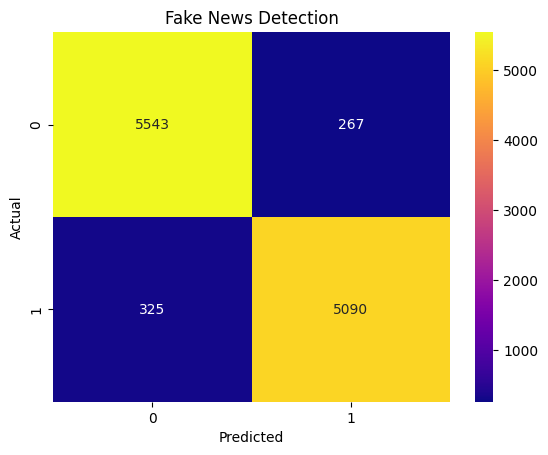

In [15]:
cm = confusion_matrix(y_test, y_predict)

sns.heatmap(cm, annot=True, fmt="d", cmap="plasma")

plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Fake News Detection")

plt.show()

In [16]:
user_news = input("Enter the news article:\n")

clean = clean_text(user_news)

vector = vectorizer.transform([clean]).toarray()

prediction = model.predict(vector)

if prediction[0] == 1:
    print("\nIt is REAL news.")
else:
    print("\nIt is FAKE news.")


It is FAKE news.
